In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Dataset: Fashion MNIST

Vi använder Fashion MNIST-datasetet som innehåller 28x28 pixlar gråskalebilder av klädesplagg.

Datan delas upp i träningsdata och testdata:

- Träningsdata används för att lära modellen
- Testdata används för att utvärdera modellen efter träning

In [2]:
# Laddar in Fashion MNIST-datasetet från Keras
fashion_mnist = keras.datasets.fashion_mnist

# Delar upp datan i träningsdata och testdata
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

## Datans struktur

Undersöker datans form för att förstå hur många bilder vi har och hur de är strukturerade.

Varje bild är 28x28 pixlar och lagras som en matris med siffror.

In [3]:
# Skriver ut form (shape) på tränings- och testdata för att förstå datans storlek
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Klassnamn

Eftersom labels i datan är siffror (0–9) använder vi en lista med klassnamn för att göra resultaten mer begripliga.

In [4]:
# Lista med klassnamn som motsvarar siffrorna (0–9) i datasetet
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


## Visualisering av en bild

Visar en enskild bild från datasetet för att förstå hur datan ser ut och hur den kopplas till rätt klass.

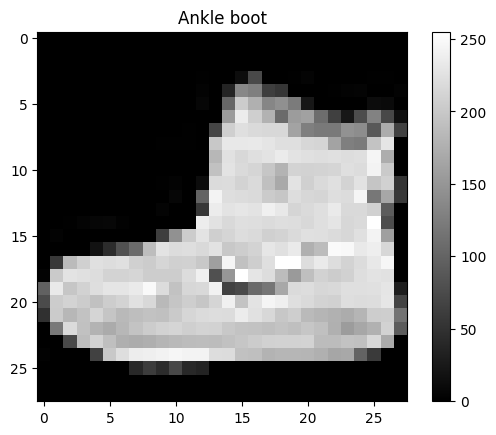

In [5]:
# Visar första bilden i träningsdatan
plt.imshow(X_train[0], cmap='gray')

# Lägger till titel med rätt klassnamn för bilden
plt.title(class_names[y_train[0]])

# Visar färgskalan (pixelvärden)
plt.colorbar()
plt.show()

## Flera exempelbilder

Visar flera bilder samtidigt för att få en bättre känsla för variationen i datasetet och hur olika klasser ser ut.

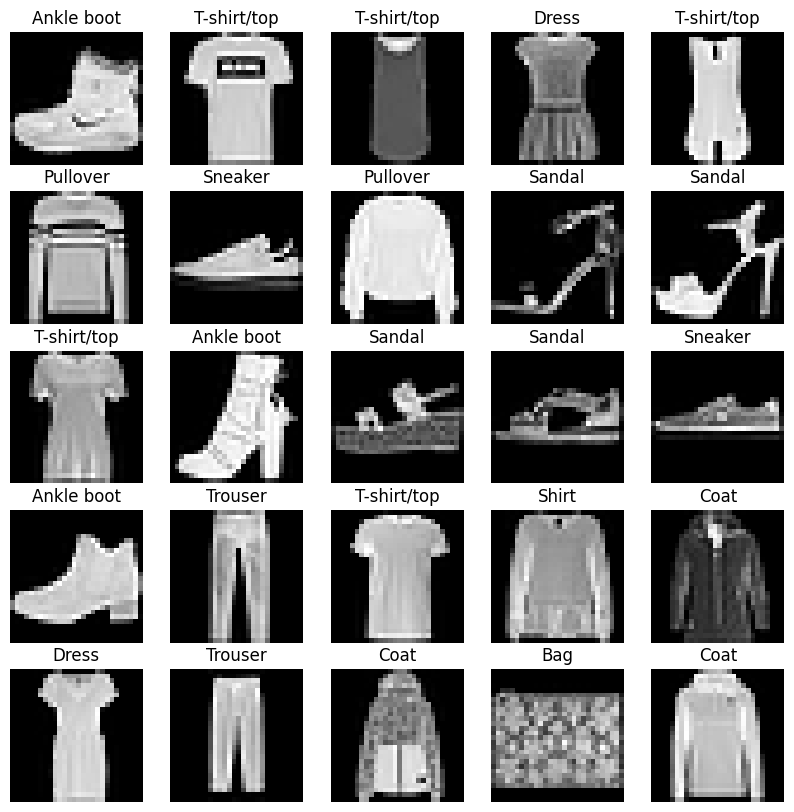

In [6]:
# Visar de första 25 bilderna i träningsdatan i ett 5x5 rutnät,
# tillsammans med respektive klassnamn för att enkelt kunna koppla bild till kategori
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

## Klassfördelning

Räknar antal bilder per klass för att se om datasetet är balanserat.

Ett balanserat dataset är viktigt eftersom modellen då tränas jämnt på alla klasser.

In [7]:
# Räknar hur många bilder som finns i varje klass i träningsdatan
unique, counts = np.unique(y_train, return_counts=True)

# Skriver ut antal bilder per klass för att kontrollera datans fördelning
for label, count in zip(unique, counts):
    print(class_names[label], ':', count)

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


## X

In [8]:
# Skapa valideringsset

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (48000, 28, 28)
X_val: (12000, 28, 28)
y_train: (48000,)
y_val: (12000,)


## X

In [9]:
# Normalisera

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

X_test_norm = X_test.astype("float32") / 255.0

print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test_norm.min(), X_test_norm.max())
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0
X_train shape: (48000, 28, 28)


## X

In [10]:
# Basmodell

baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


## X

In [11]:
# Compilerar och tränar basmodellen

from utils import model_compile_and_fit

baseline_model_train = model_compile_and_fit(baseline_model, X_train, y_train, X_val, y_val)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8540 - loss: 0.4089 - val_accuracy: 0.8846 - val_loss: 0.3207
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9011 - loss: 0.2746 - val_accuracy: 0.8967 - val_loss: 0.2849
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9172 - loss: 0.2261 - val_accuracy: 0.9023 - val_loss: 0.2725
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9325 - loss: 0.1879 - val_accuracy: 0.9053 - val_loss: 0.2686
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9437 - loss: 0.1563 - val_accuracy: 0.9052 - val_loss: 0.2724
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9538 - loss: 0.1293 - val_accuracy: 0.9051 - val_loss: 0.2901
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9628 - loss: 0.1066 - val_accuracy: 0.9058 - val_loss: 0.3023


## X

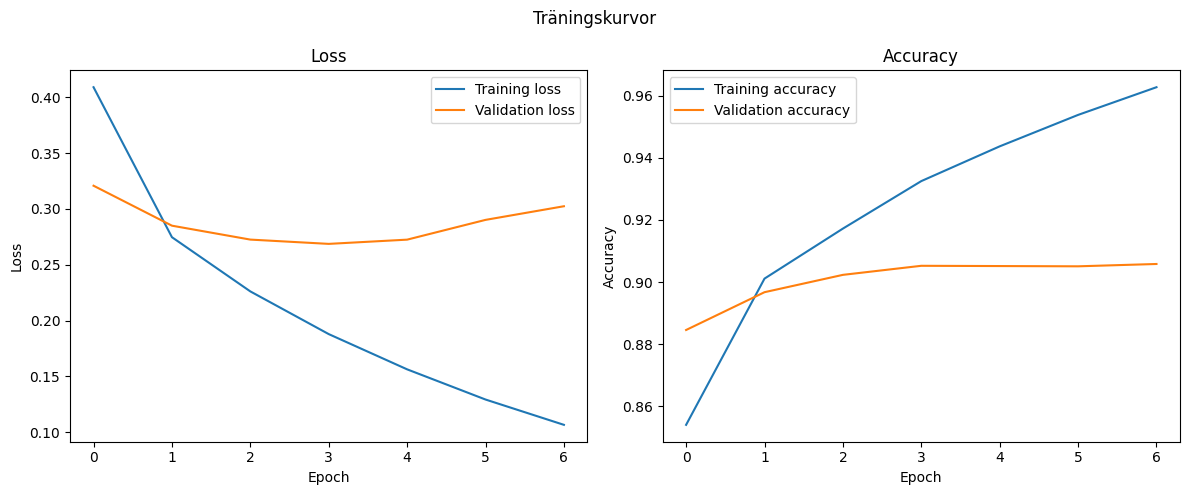

In [13]:
from utils import plot_history

plot_history(baseline_model_train)

## X

In [ ]:
# Optimerad modell

optimized_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])